# BRENDA kinetic coverage of the serum panel

## Scope

BRENDA is the broad kinetic source available for the serum panel; SABIO-RK
returned no records and the qMSP-MS and ADAMTS13 tables were not retrievable.
This notebook measures what the licensed 2026.1 snapshot provides for the 40 EC
numbers of the manifest.

Three counts are reported separately, because only the last is a usable label
for the MEROPS to kinetics regression:

1. quantitative entries per protease and parameter type;
2. entries whose substrate sequence is recoverable from the free-text
   description;
3. entries whose scissile bond is known, so that a $P_4 \ldots P_4'$ window can
   be constructed.

The extraction is performed by
`assets/scripts/downloads/serum_proteolysis_calibration/ingest_brenda.py`,
which streams the 677 MB archive once and writes the table read here. Values
and units are preserved as BRENDA reports them; unit conversion belongs to a
later normalization stage.

## Inputs and outputs

Inputs:
`data/serum_proteolysis_calibration/processed/kinetics/brenda_serum_proteases.parquet`
with its coverage sidecar, and `manifests/serum_proteases.tsv`.

Output: `results/0_09_brenda_coverage.csv`.

In [1]:
import json
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    CleavageSiteSource,
    SubstrateKind,
    infer_cleavage_bond,
    parse_substrate,
    resolvable_subsites,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
# Parameter families, in the order they are reported.
PARAMETER_ORDER = ["kcat_km_value", "turnover_number", "km_value"]

In [3]:
availability = common.describe_source(common.BRENDA_KINETICS)
print(f"BRENDA table: {availability['path']} | exists={availability['exists']} | "
      f"{availability['bytes'] / 1e6:.2f} MB")
if not availability["exists"]:
    raise FileNotFoundError(
        "Run assets/scripts/downloads/serum_proteolysis_calibration/ingest_brenda.py first."
    )

BRENDA table: data/serum_proteolysis_calibration/processed/kinetics/brenda_serum_proteases.parquet | exists=True | 0.12 MB


In [4]:
kinetics = pd.read_parquet(common.BRENDA_KINETICS)
coverage_sidecar = json.loads(
    common.BRENDA_KINETICS.with_name(common.BRENDA_KINETICS.stem + "_coverage.json").read_text()
)
manifest = common.load_serum_manifest()

print(f"entries: {len(kinetics):,} | EC numbers: {kinetics['ec_number'].nunique()}")
print(f"requested EC numbers: {coverage_sidecar['n_requested_ec']} | "
      f"present in BRENDA: {coverage_sidecar['n_ec_present_in_brenda']} | "
      f"absent: {coverage_sidecar['n_ec_absent_from_brenda']}")
print()
print(kinetics.groupby(["parameter_type", "value_kind"]).size().unstack(fill_value=0).to_string())

entries: 3,803 | EC numbers: 40
requested EC numbers: 40 | present in BRENDA: 40 | absent: 0

value_kind       numeric  range
parameter_type                 
kcat_km_value        376      3
km_value            1843      9
turnover_number     1554     18


## Proteases reachable through an EC number

A protease reaches BRENDA only through its EC number. Entries whose UniProt
mapping produced no EC number, and entries whose mapping is ambiguous, cannot
be queried. Their absence from the results is a property of the query path, not
a measurement.

In [5]:
included = manifest[manifest["include_in_hydrolysis_model"]]
queryable = included[included["ec_number"] != ""]
unqueryable = included[included["ec_number"] == ""]

print(f"included in the hydrolysis model: {len(included)}")
print(f"  queryable via an EC number:     {len(queryable)}")
print(f"  structurally unqueryable:       {len(unqueryable)}")
print()
print(unqueryable[["merops_code", "merops_name", "mapping_status"]].to_string(index=False))

included in the hydrolysis model: 54
  queryable via an EC number:     42
  structurally unqueryable:       12

merops_code                                         merops_name                     mapping_status
    M10.013                          matrix metallopeptidase-13                    mapped_reviewed
    M14.004                                  carboxypeptidase N unresolved_multiple_human_mappings
    S01.015                                       tryptase beta unresolved_multiple_human_mappings
    S01.033                     factor VII-activating peptidase                    mapped_reviewed
    S01.132 mannan-binding lectin-associated serine peptidase-3                    mapped_reviewed
    S01.139                                          granzyme M                    mapped_reviewed
    S01.143                                      tryptase alpha unresolved_multiple_human_mappings
    S01.146                                          granzyme K                    mapped_review

## Substrate and cleavage-site resolution

Each entry names its substrate as free text. The parser recovers residues where
they are unambiguous and returns nothing otherwise. The cleavage site is
inferred only where a leaving reporter group fixes it; an internally quenched
substrate has an internal site that the database does not report.

The difference between the two counts is the pool whose sequences are known and
whose bond would have to be taken from the source publication.

In [6]:
numeric = kinetics.query("value_kind == 'numeric'").copy()
parses = [parse_substrate(text) for text in numeric["substrate_raw"]]
bonds_and_sources = [infer_cleavage_bond(parse) for parse in parses]

numeric["substrate_kind"] = [parse.kind.value for parse in parses]
numeric["substrate_sequence"] = [parse.sequence for parse in parses]
numeric["substrate_length"] = [len(parse.sequence) for parse in parses]
numeric["is_fret"] = [parse.is_fret for parse in parses]
numeric["cleavage_site_source"] = [source.value for _, source in bonds_and_sources]
numeric["n_resolvable_subsites"] = [resolvable_subsites(parse) for parse in parses]
numeric["sequence_resolved"] = numeric["substrate_length"] > 0
numeric["window_resolved"] = numeric["n_resolvable_subsites"] > 0

print(f"numeric entries: {len(numeric):,}")
print()
print("substrate kind:")
print(numeric["substrate_kind"].value_counts().to_string())
print()
print("cleavage-site provenance:")
print(numeric["cleavage_site_source"].value_counts().to_string())
print()
print(f"sequence resolved: {numeric['sequence_resolved'].sum():,} "
      f"({numeric['sequence_resolved'].mean():.1%})")
print(f"window resolved:   {numeric['window_resolved'].sum():,} "
      f"({numeric['window_resolved'].mean():.1%})")

## The gap between the two counts is the recoverable pool: entries whose residues
## are known but whose scissile bond is not reported by BRENDA.
recoverable = numeric.query("sequence_resolved and not window_resolved")
print()
print(f"sequence known but bond unknown: {len(recoverable):,}")
print(f"  of which internally quenched (FRET), site documented in the source paper: "
      f"{int(recoverable['is_fret'].sum()):,} "
      f"({recoverable.query('is_fret')['substrate_sequence'].nunique()} distinct sequences)")
print(f"  of which plain peptides with no reporter at all: "
      f"{int((~recoverable['is_fret']).sum()):,}")

numeric entries: 3,773

substrate kind:
substrate_kind
peptide_three_letter    1230
peptide_one_letter       908
unresolved               753
macromolecule            658
single_residue           224

cleavage-site provenance:
cleavage_site_source
unknown_internal    1521
not_applicable      1411
reporter_group       841

sequence resolved: 2,362 (62.6%)
window resolved:   841 (22.3%)

sequence known but bond unknown: 1,521
  of which internally quenched (FRET), site documented in the source paper: 463 (170 distinct sequences)
  of which plain peptides with no reporter at all: 1,058


In [7]:
## A sample of what each resolution class actually looks like
for kind in ["peptide_three_letter", "peptide_one_letter", "single_residue", "macromolecule", "unresolved"]:
    subset = numeric.query("substrate_kind == @kind")
    if subset.empty:
        continue
    examples = subset["substrate_raw"].drop_duplicates().head(3).tolist()
    print(f"{kind:22s} n={len(subset):5d}  e.g. {' | '.join(example[:44] for example in examples)}")

peptide_three_letter   n= 1230  e.g. Gly-Pro-p-nitroanilide | Ala-Pro-7-amido-4-trifluoromethyl coumarin | Gly-Pro-4-nitroanilide
peptide_one_letter     n=  908  e.g. o-aminobenzoyl-GFSPFRN-(N-2,4-dinitrophenyl) | o-aminobenzoyl-GFSPFAQ-(N-2,4-dinitrophenyl) | o-aminobenzoyl-GFSPFLQ-(N-2,4-dinitrophenyl)
single_residue         n=  224  e.g. Ala-2-naphthylamide | Leu-2-naphthylamide | L-Leu-4-nitroanilide
macromolecule          n=  658  e.g. angiotensin I | Substance P | neurotensin
unresolved             n=  753  e.g. 9-(L-leucylamino)-5H-benzo[a]phenoxazin-5-im | BRI peptide (1-23) | more


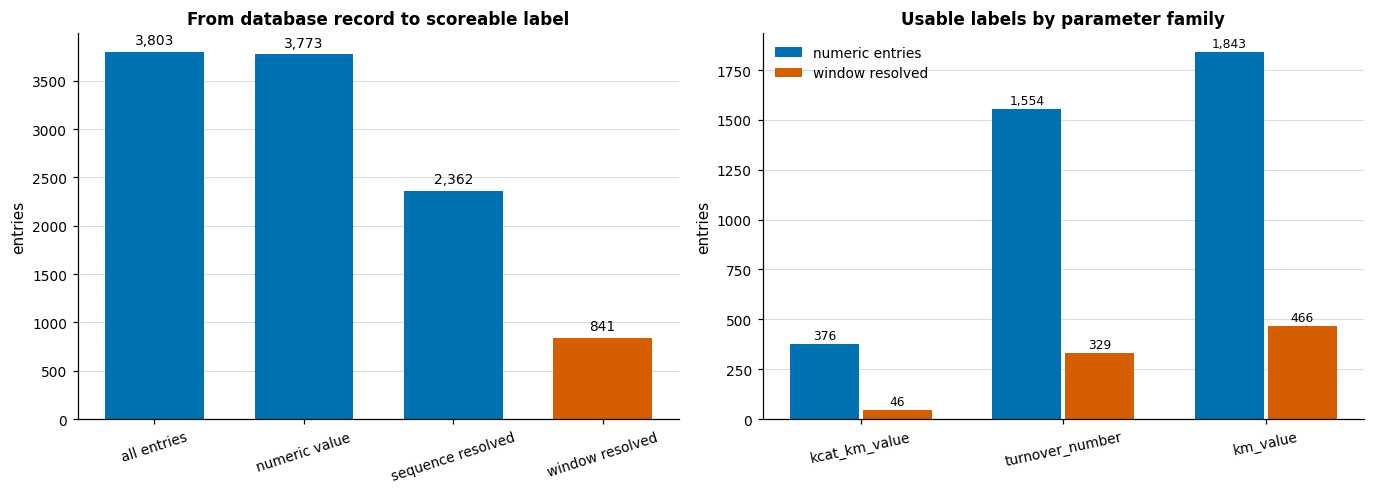

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))

ax = axes[0]
funnel_labels = ["all entries", "numeric value", "sequence resolved", "window resolved"]
funnel_values = [
    len(kinetics),
    len(numeric),
    int(numeric["sequence_resolved"].sum()),
    int(numeric["window_resolved"].sum()),
]
bars = ax.bar(
    funnel_labels,
    funnel_values,
    color=[common.CATEGORICAL_COLORS[0]] * 3 + [common.CATEGORICAL_COLORS[1]],
    width=0.66,
)
for bar, value in zip(bars, funnel_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(funnel_values) * 0.02,
        f"{value:,}",
        ha="center",
        fontsize=9,
    )
ax.set_ylabel("entries")
ax.set_title("From database record to scoreable label")
ax.tick_params(axis="x", rotation=18)
ax.grid(axis="x", visible=False)

ax = axes[1]
by_parameter = (
    numeric.groupby("parameter_type")
    .agg(entries=("value_raw", "size"), window=("window_resolved", "sum"))
    .reindex(PARAMETER_ORDER)
    .dropna()
)
positions = np.arange(len(by_parameter))
ax.bar(positions - 0.18, by_parameter["entries"], width=0.34, color=common.CATEGORICAL_COLORS[0], label="numeric entries")
ax.bar(positions + 0.18, by_parameter["window"], width=0.34, color=common.CATEGORICAL_COLORS[1], label="window resolved")
for position, (entries, window) in enumerate(zip(by_parameter["entries"], by_parameter["window"])):
    ax.text(position - 0.18, entries + 25, f"{int(entries):,}", ha="center", fontsize=8)
    ax.text(position + 0.18, window + 25, f"{int(window):,}", ha="center", fontsize=8)
ax.set_xticks(positions)
ax.set_xticklabels(by_parameter.index, rotation=12)
ax.set_ylabel("entries")
ax.set_title("Usable labels by parameter family")
ax.legend()
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## Coverage per protease

The regression of the specification is fitted per protease, so the relevant
quantity is the number of distinct window-resolved substrates each enzyme has.
A held-out split on sequences requires enough distinct sequences on both
sides.

In [9]:
ec_to_codes = (
    queryable.groupby("ec_number")["merops_code"].apply(lambda codes: ";".join(sorted(codes))).to_dict()
)

per_protease = (
    numeric.groupby("ec_number")
    .agg(
        n_numeric_entries=("value_raw", "size"),
        n_kcat_km=("parameter_type", lambda values: int((values == "kcat_km_value").sum())),
        n_sequence_resolved=("sequence_resolved", "sum"),
        n_window_resolved=("window_resolved", "sum"),
        n_unique_sequences=("substrate_sequence", lambda values: values[values != ""].nunique()),
        n_references=("pmids", lambda values: values[values != ""].nunique()),
    )
    .reset_index()
)
per_protease["n_unique_window_substrates"] = (
    numeric.query("window_resolved")
    .groupby("ec_number")["substrate_sequence"]
    .nunique()
    .reindex(per_protease["ec_number"])
    .fillna(0)
    .astype(int)
    .to_numpy()
)
per_protease["merops_codes"] = per_protease["ec_number"].map(ec_to_codes)
per_protease["n_kcat_km_window"] = (
    numeric.query("window_resolved and parameter_type == 'kcat_km_value'")
    .groupby("ec_number")
    .size()
    .reindex(per_protease["ec_number"])
    .fillna(0)
    .astype(int)
    .to_numpy()
)

print(
    per_protease.sort_values("n_unique_window_substrates", ascending=False)
    .head(15)[
        [
            "ec_number",
            "merops_codes",
            "n_numeric_entries",
            "n_sequence_resolved",
            "n_window_resolved",
            "n_unique_window_substrates",
            "n_kcat_km_window",
            "n_references",
        ]
    ]
    .to_string(index=False)
)

ec_number    merops_codes  n_numeric_entries  n_sequence_resolved  n_window_resolved  n_unique_window_substrates  n_kcat_km_window  n_references
3.4.21.39         S01.140                116                  103                 77                          29                 2            10
 3.4.11.2         M01.001                 29                   28                 28                          16                 0             6
3.4.21.68         S01.232                391                  350                 60                          16                 5            13
3.4.21.76         S01.134                155                  149                 40                          13                 2            10
 3.4.14.5         S09.003                156                  153                119                          13                 0            17
 3.4.21.5         S01.217                194                  102                 71                          12                 8

In [10]:
for threshold in [1, 5, 10, 20, 30]:
    count = int((per_protease["n_unique_window_substrates"] >= threshold).sum())
    print(f"proteases with >= {threshold:2d} distinct window-resolved substrates: {count}")

proteases with >=  1 distinct window-resolved substrates: 22
proteases with >=  5 distinct window-resolved substrates: 12
proteases with >= 10 distinct window-resolved substrates: 9
proteases with >= 20 distinct window-resolved substrates: 1
proteases with >= 30 distinct window-resolved substrates: 0


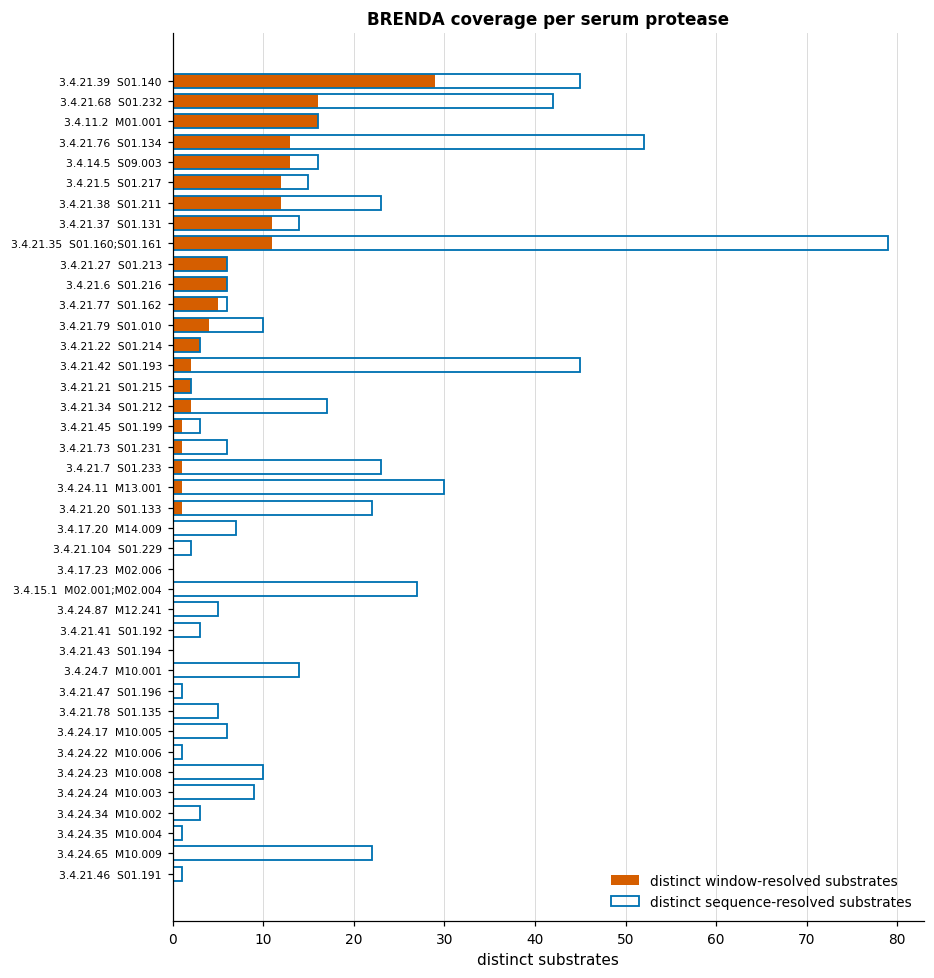

In [11]:
fig, ax = plt.subplots(figsize=(8.6, 9.0))
ordered = per_protease.sort_values("n_unique_window_substrates").reset_index(drop=True)
ax.barh(
    ordered.index,
    ordered["n_unique_window_substrates"],
    color=common.CATEGORICAL_COLORS[1],
    height=0.7,
    label="distinct window-resolved substrates",
)
ax.barh(
    ordered.index,
    ordered["n_unique_sequences"],
    color="none",
    edgecolor=common.CATEGORICAL_COLORS[0],
    linewidth=1.2,
    height=0.7,
    label="distinct sequence-resolved substrates",
)
ax.set_yticks(ordered.index)
ax.set_yticklabels([f"{row.ec_number}  {row.merops_codes[:18]}" for row in ordered.itertuples()], fontsize=7)
ax.set_xlabel("distinct substrates")
ax.set_title("BRENDA coverage per serum protease")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## Extent of the resolvable windows

A regression fitted on reporter substrates transfers to antimicrobial peptides
only where the sequence contexts overlap. Reporter substrates are short by
construction and their prime side is occupied by the reporter group, so the
quantity reported below is the non-prime context they can populate.

In [12]:
window_entries = numeric.query("window_resolved")
print("non-prime context length available in window-resolved substrates:")
print(window_entries["n_resolvable_subsites"].value_counts().sort_index().to_string())
print()
print(f"distinct window-resolved substrate sequences across the whole panel: "
      f"{window_entries['substrate_sequence'].nunique()}")
print(f"of those reaching the full four non-prime subsites: "
      f"{window_entries.query('n_resolvable_subsites == 4')['substrate_sequence'].nunique()}")
print()
print("most frequent window-resolved substrates:")
print(window_entries["substrate_raw"].value_counts().head(8).to_string())

non-prime context length available in window-resolved substrates:
n_resolvable_subsites
1     32
2    237
3    411
4    161

distinct window-resolved substrate sequences across the whole panel: 137
of those reaching the full four non-prime subsites: 35

most frequent window-resolved substrates:
substrate_raw
N-methylsulfonyl-D-Phe-Gly-Arg-p-nitroanilide                         43
Gly-Pro-4-nitroanilide                                                42
D-Ile-Pro-Arg-p-nitroanilide                                          38
L-pyroGlu-L-Pro-L-Arg-4-nitroanilide                                  26
Ala-Pro-7-amido-4-methylcoumarin                                      25
D-Ile-Pro-Arg-4-nitroanilide                                          24
tert-butyloxycarbonyl-Asp(benzyl)-Pro-Arg-7-amido-4-methylcoumarin    17
D-Pro-Phe-Arg-4-nitroanilide                                          16


## Coverage table

One row per EC number with the counts that determine whether a
protease-specific model, a scale anchor, or neither is possible. Proteases that
cannot be queried are retained with an explicit verdict.
`0_14_dataset_definition.ipynb` combines this table with the other
sources.

In [13]:
coverage = per_protease.copy()
coverage["source"] = "brenda_2026.1"
coverage["measurement_types"] = (
    numeric.groupby("ec_number")["parameter_type"]
    .apply(lambda values: ";".join(sorted(values.unique())))
    .reindex(coverage["ec_number"])
    .to_numpy()
)
coverage["brenda_verdict"] = np.select(
    [
        coverage["n_unique_window_substrates"] >= 20,
        coverage["n_unique_window_substrates"] >= 5,
        coverage["n_unique_window_substrates"] >= 1,
    ],
    ["protease_specific_model_possible", "scale_anchor_only", "single_anchor"],
    default="no_usable_label",
)

## Proteases that cannot reach BRENDA at all stay visible as blocked, not absent
blocked = pd.DataFrame(
    {
        "ec_number": "",
        "merops_codes": unqueryable["merops_code"].to_numpy(),
        "n_numeric_entries": 0,
        "n_kcat_km": 0,
        "n_sequence_resolved": 0,
        "n_window_resolved": 0,
        "n_unique_sequences": 0,
        "n_references": 0,
        "n_unique_window_substrates": 0,
        "n_kcat_km_window": 0,
        "source": "brenda_2026.1",
        "measurement_types": "",
        "brenda_verdict": "not_queryable_no_ec",
    }
)
coverage = pd.concat([coverage, blocked], ignore_index=True)

print(coverage["brenda_verdict"].value_counts().to_string())
destination = common.save_result(coverage, "0_09_brenda_coverage.csv")
print(f"\nwritten: {destination.relative_to(common.ROOT)}")
coverage.sort_values("n_unique_window_substrates", ascending=False).head(12)

brenda_verdict
no_usable_label                     18
not_queryable_no_ec                 12
scale_anchor_only                   11
single_anchor                       10
protease_specific_model_possible     1

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_09_brenda_coverage.csv


,ec_number,n_numeric_entries,n_kcat_km,n_sequence_resolved,n_window_resolved,n_unique_sequences,n_references,n_unique_window_substrates,merops_codes,n_kcat_km_window,source,measurement_types,brenda_verdict
14,3.4.21.39,116,16,103,77,45,10,29,S01.140,2,brenda_2026.1,kcat_km_value;km_value;turnover_number,protease_specific_model_possible
0,3.4.11.2,29,0,28,28,16,6,16,M01.001,0,brenda_2026.1,km_value;turnover_number,scale_anchor_only
23,3.4.21.68,391,5,350,60,42,13,16,S01.232,5,brenda_2026.1,kcat_km_value;km_value;turnover_number,scale_anchor_only
1,3.4.14.5,156,0,153,119,16,17,13,S09.003,0,brenda_2026.1,km_value;turnover_number,scale_anchor_only
26,3.4.21.76,155,48,149,40,52,10,13,S01.134,2,brenda_2026.1,kcat_km_value;km_value;turnover_number,scale_anchor_only
21,3.4.21.5,194,16,102,71,15,26,12,S01.217,8,brenda_2026.1,kcat_km_value;km_value;turnover_number,scale_anchor_only
13,3.4.21.38,79,8,67,37,23,5,12,S01.211,4,brenda_2026.1,kcat_km_value;km_value;turnover_number,scale_anchor_only
11,3.4.21.35,244,44,238,29,79,15,11,S01.160;S01.161,0,brenda_2026.1,kcat_km_value;km_value;turnover_number,scale_anchor_only
12,3.4.21.37,91,0,87,47,14,11,11,S01.131,0,brenda_2026.1,km_value;turnover_number,scale_anchor_only
9,3.4.21.27,116,3,52,52,6,18,6,S01.213,1,brenda_2026.1,kcat_km_value;km_value;turnover_number,scale_anchor_only
